In [3]:
! pip install -q kaggle

In [94]:
#Importing libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

In [95]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(device)
else:
    device = torch.device("cpu")
    print(device)

cuda


In [96]:
from google.colab import files
files.upload()

{}

In [21]:
 ! chmod 600 ~/.kaggle/kaggle.json

In [18]:
! kaggle datasets list

ref                                                        title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------  ---------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
adilshamim8/student-depression-dataset                     Student Depression Dataset                         467020  2025-03-13 03:12:30.423000          14315        215  1.0              
zahidmughal2343/amazon-sales-2025                          Amazon Sales 2025                                    3617  2025-04-03 22:08:13.607000           2159         31  1.0              
vinothkannaece/mobiles-and-laptop-sales-data               Mobiles & laptop Sales Data                       3242055  2025-03-24 05:03:52.657000           1853         23  1.0              
atharvasoundankar/spotify-global-streaming-data-20

In [22]:
#!/bin/bash
! kaggle datasets download vinayjayanti/brain-tumor-mris

Dataset URL: https://www.kaggle.com/datasets/vinayjayanti/brain-tumor-mris
License(s): apache-2.0
brain-tumor-mris.zip: Skipping, found more recently modified local copy (use --force to force download)


In [27]:
! mkdir data

In [28]:
! unzip brain-tumor-mris.zip -d data

Streaming output truncated to the last 5000 lines.
  inflating: data/brain_tumor_mris/Training/glioma/Tr-gl_0258.jpg  
  inflating: data/brain_tumor_mris/Training/glioma/Tr-gl_0259.jpg  
  inflating: data/brain_tumor_mris/Training/glioma/Tr-gl_0260.jpg  
  inflating: data/brain_tumor_mris/Training/glioma/Tr-gl_0261.jpg  
  inflating: data/brain_tumor_mris/Training/glioma/Tr-gl_0262.jpg  
  inflating: data/brain_tumor_mris/Training/glioma/Tr-gl_0263.jpg  
  inflating: data/brain_tumor_mris/Training/glioma/Tr-gl_0264.jpg  
  inflating: data/brain_tumor_mris/Training/glioma/Tr-gl_0265.jpg  
  inflating: data/brain_tumor_mris/Training/glioma/Tr-gl_0266.jpg  
  inflating: data/brain_tumor_mris/Training/glioma/Tr-gl_0267.jpg  
  inflating: data/brain_tumor_mris/Training/glioma/Tr-gl_0268.jpg  
  inflating: data/brain_tumor_mris/Training/glioma/Tr-gl_0269.jpg  
  inflating: data/brain_tumor_mris/Training/glioma/Tr-gl_0270.jpg  
  inflating: data/brain_tumor_mris/Training/glioma/Tr-gl_0271.jpg

In [97]:
transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # transforms.Normalize((0.5,), (0.5,)) # if you want to normlize the data
    # transforms.Lambda(lambda x: x.repeat(3, 1, 1))  # Convert grayscale to RGB
])

In [120]:
MRI_Data_train = datasets.ImageFolder(root='/content/data/brain_tumor_mris/Testing', transform=transforms)
MRI_Data_test = datasets.ImageFolder(root='/content/data/brain_tumor_mris/Testing', transform=transforms)
MRI_Data_validation = datasets.ImageFolder(root='/content/data/brain_tumor_mris/Validation', transform=transforms)

In [121]:
MRI_Data_train

Dataset ImageFolder
    Number of datapoints: 576
    Root location: /content/data/brain_tumor_mris/Testing
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )

In [122]:
MRI_Data_train.classes

['glioma', 'meningioma', 'notumor', 'pituitary']

In [123]:
MRI_Data_train = DataLoader(MRI_Data_train, batch_size=32, shuffle=True)
MRI_Data_test = DataLoader(MRI_Data_test, batch_size=32, shuffle=True)
MRI_Data_validation = DataLoader(MRI_Data_validation, batch_size=32, shuffle=True)

In [124]:
MRI_Data_train.dataset.classes, MRI_Data_test.dataset.classes, MRI_Data_validation.dataset.classes

(['glioma', 'meningioma', 'notumor', 'pituitary'],
 ['glioma', 'meningioma', 'notumor', 'pituitary'],
 ['glioma', 'meningioma', 'notumor', 'pituitary'])

In [115]:
len(MRI_Data_validation.dataset)

36

In [104]:
for i , data in enumerate(MRI_Data_train):
    print(i, data[0].shape, data[1].shape)
    print(data)
    break

0 torch.Size([32, 3, 224, 224]) torch.Size([32])
[tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0

In [105]:
#Function for showing batches

def show_MRI_batch(dataloader, title="Batch of CT Images"):
    images, labels = next(iter(dataloader))
    fig, axes = plt.subplots(4, 8, figsize=(15, 8))
    fig.suptitle(title)

    for i, ax in enumerate(axes.flatten()):
        if i < len(images):
            img = images[i].permute(1, 2, 0)  # Convert tensor image for plotting
            ax.imshow(img)
            ax.set_title(MRI_Data_train.dataset.classes[labels[i]])
            ax.axis('off')
    plt.show()

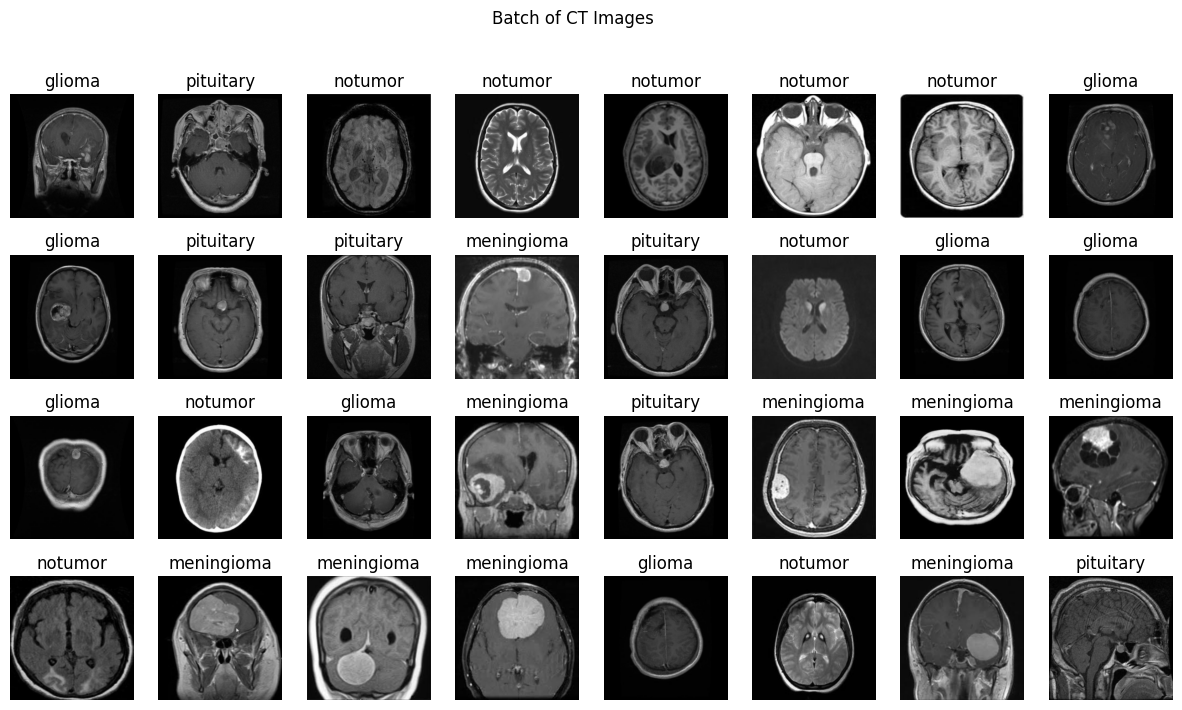

In [106]:
show_MRI_batch(MRI_Data_train)

# Model 1

In [129]:
import torch
import torch.nn as nn

# Magnetic Resonance Imaging CNN Model
class MRIModel(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.layer_stack = nn.Sequential(
            # Conv Layer Block 1
            nn.Conv2d(in_channels=in_channels, out_channels=32, kernel_size=3, stride=1, padding=1),  # 224x224x32
            nn.ReLU(),

            # Conv Layer Block 2
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # 224x224x64
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 112x112x64

            # Conv Layer Block 3
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),  # 112x112x128
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 56x56x128

            # Conv Layer Block 4
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),  # 56x56x256
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 28x28x256

            # Conv Layer Block 5
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),  # 28x28x512
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=4, stride=4),  # 7x7x512

            nn.Flatten(),  # 7*7*512 = 25088
            nn.Linear(7 * 7 * 512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.layer_stack(x)

# Instantiate
mri_model = MRIModel(in_channels=3, num_classes=4)
# Move the model to the GPU
mri_model = mri_model.to(device)
print(mri_model)

MRIModel(
  (layer_stack): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU()
    (13): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (14): Flatten(start_dim=1, end_dim=-1)
    (15): Linear(in_features=25088, out_features=256, bias=True)
    (16): ReLU()
    (17): Dropout(p=0.5, inplace=Fals

In [130]:
from torchsummary import summary
summary(mri_model , input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
              ReLU-2         [-1, 32, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          18,496
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
         MaxPool2d-8          [-1, 128, 56, 56]               0
            Conv2d-9          [-1, 256, 56, 56]         295,168
             ReLU-10          [-1, 256, 56, 56]               0
        MaxPool2d-11          [-1, 256, 28, 28]               0
           Conv2d-12          [-1, 512, 28, 28]       1,180,160
             ReLU-13          [-1, 512, 28, 28]               0
        MaxPool2d-14            [-1, 51

In [131]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(mri_model.parameters(),lr=0.001)

In [132]:
from tqdm import tqdm
import matplotlib.pyplot as plt

num_epochs = 30
best_val_acc = 0.0

# For plotting
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    # Training loop
    mri_model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in tqdm(MRI_Data_train, desc=f"Epoch {epoch+1} - Training"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = mri_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Accuracy
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(MRI_Data_train)
    train_acc = 100 * train_correct / train_total

    # Validation loop
    mri_model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.inference_mode():
        for images, labels in tqdm(MRI_Data_validation, desc=f"Epoch {epoch+1} - Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = mri_model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(MRI_Data_validation)
    val_acc = 100 * val_correct / val_total

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Print metrics
    # print(f"\n📊 Epoch [{epoch+1}/{num_epochs}]")
    # print(f"  🏋️ Train Loss: {train_loss:.4f}, Accuracy: {train_acc:.2f}%")
    # print(f"  📉 Val Loss:   {val_loss:.4f}, Accuracy: {val_acc:.2f}%")
    train_acc = 100 * train_correct / train_total
    val_acc = 100 * val_correct / val_total

    print(f"  🏋️ Train Loss: {train_loss:.4f}, Accuracy: {train_acc:.2f}%")
    print(f"  📉 Val Loss:   {val_loss:.4f}, Accuracy: {val_acc:.2f}%")


    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(mri_model.state_dict(), "best_mri_model1.pth")
        print("  ✅ Saved new best model!")


Epoch 1 - Validation: 100%|██████████| 18/18 [00:03<00:00,  5.81it/s]


  🏋️ Train Loss: 1.3499, Accuracy: 26.39%
  📉 Val Loss:   1.4666, Accuracy: 25.69%
  ✅ Saved new best model!


Epoch 2 - Validation: 100%|██████████| 18/18 [00:04<00:00,  4.45it/s]


  🏋️ Train Loss: 1.1665, Accuracy: 47.22%
  📉 Val Loss:   1.2423, Accuracy: 43.40%
  ✅ Saved new best model!


Epoch 3 - Validation: 100%|██████████| 18/18 [00:03<00:00,  5.74it/s]


...

  🏋️ Train Loss: 0.1563, Accuracy: 93.40%
  📉 Val Loss:   1.1627, Accuracy: 69.97%


Epoch 29 - Validation: 100%|██████████| 18/18 [00:03<00:00,  5.27it/s]


  🏋️ Train Loss: 0.1136, Accuracy: 96.01%
  📉 Val Loss:   1.1713, Accuracy: 74.48%


Epoch 30 - Validation: 100%|██████████| 18/18 [00:03<00:00,  5.64it/s]

  🏋️ Train Loss: 0.0829, Accuracy: 96.70%
  📉 Val Loss:   1.2801, Accuracy: 72.74%


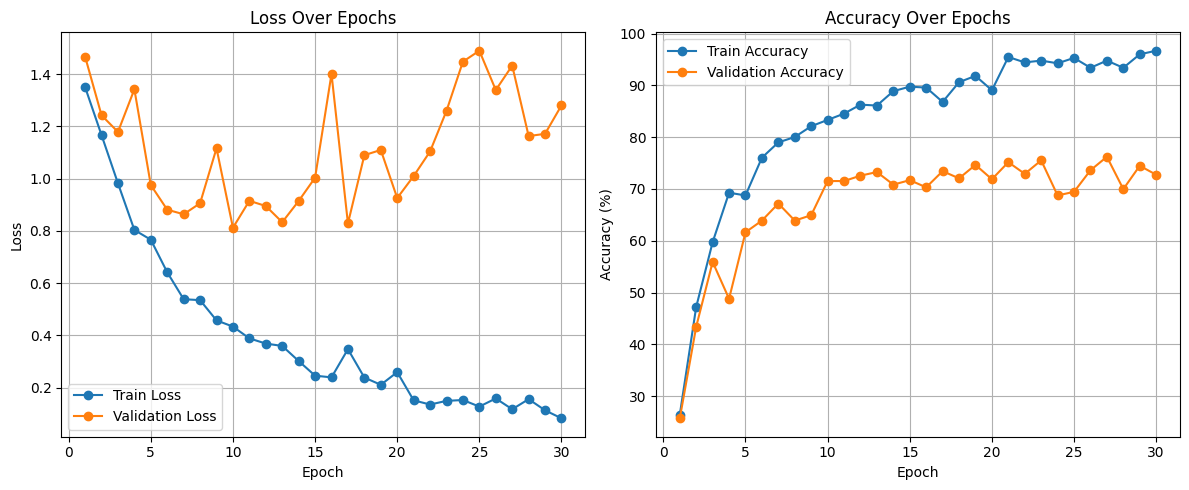

In [133]:
 # ========================
# 📈 Plot Loss & Accuracy
# ========================
epochs_range = range(1, num_epochs + 1)
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss', marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Over Epochs")
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Over Epochs")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

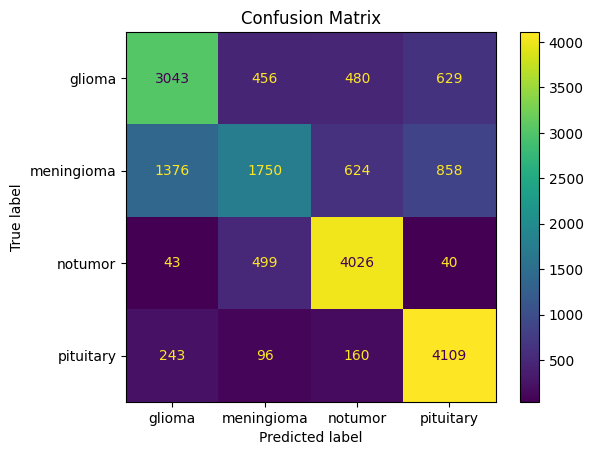

In [134]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(mri_all_labels, mri_all_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['glioma', 'meningioma', 'notumor', 'pituitary'])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [135]:
# Final test accuracy
mri_model.eval()
test_correct = 0
test_total = 0

with torch.inference_mode():
    for images, labels in tqdm(MRI_Data_test):  # Final test set
        images, labels = images.to(device), labels.to(device)
        outputs = mri_model(images)
        _, predicted = torch.max(outputs, 1)

        mri_all_labels.extend(labels.cpu().numpy())
        mri_all_predictions.extend(predicted.cpu().numpy())

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

print(f"✅ Final Test Accuracy: {100 * test_correct / test_total:.2f}%")

100%|██████████| 18/18 [00:03<00:00,  5.81it/s]

✅ Final Test Accuracy: 99.83%


# Model 2

In [116]:
import torch
import torch.nn as nn

class ImprovedMRIModel(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.layer_stack = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            nn.MaxPool2d(2),  # -> 112x112

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(),
            nn.MaxPool2d(2),  # -> 56x56

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(),
            nn.MaxPool2d(2),  # -> 28x28

            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(),
            nn.MaxPool2d(4),  # -> 7x7

            nn.Flatten(),  # 7x7x512 = 25088
            nn.Linear(7 * 7 * 512, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.layer_stack(x)

# Instantiate
mri_model = ImprovedMRIModel(in_channels=3, num_classes=4).to(device)
print(mri_model)

ImprovedMRIModel(
  (layer_stack): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): LeakyReLU(negative_slope=0.01)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): LeakyReLU(negative_slope=0.01)
    (13): MaxPool2d(kernel_size=2, stride=2, p

In [117]:
from torchsummary import summary
summary(mri_model , input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
       BatchNorm2d-2         [-1, 64, 224, 224]             128
         LeakyReLU-3         [-1, 64, 224, 224]               0
            Conv2d-4         [-1, 64, 224, 224]          36,928
       BatchNorm2d-5         [-1, 64, 224, 224]             128
         LeakyReLU-6         [-1, 64, 224, 224]               0
         MaxPool2d-7         [-1, 64, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]          73,856
       BatchNorm2d-9        [-1, 128, 112, 112]             256
        LeakyReLU-10        [-1, 128, 112, 112]               0
           Conv2d-11        [-1, 128, 112, 112]         147,584
      BatchNorm2d-12        [-1, 128, 112, 112]             256
        LeakyReLU-13        [-1, 128, 112, 112]               0
        MaxPool2d-14          [-1, 128,

In [118]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(mri_model.parameters(),lr=0.001)

In [125]:
from tqdm import tqdm
import matplotlib.pyplot as plt

num_epochs = 30
best_val_acc = 0.0

# For plotting
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    # Training loop
    mri_model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in tqdm(MRI_Data_train, desc=f"Epoch {epoch+1} - Training"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = mri_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Accuracy
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(MRI_Data_train)
    train_acc = 100 * train_correct / train_total

    # Validation loop
    mri_model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.inference_mode():
        for images, labels in tqdm(MRI_Data_validation, desc=f"Epoch {epoch+1} - Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = mri_model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(MRI_Data_validation)
    val_acc = 100 * val_correct / val_total

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Print metrics
    # print(f"\n📊 Epoch [{epoch+1}/{num_epochs}]")
    # print(f"  🏋️ Train Loss: {train_loss:.4f}, Accuracy: {train_acc:.2f}%")
    # print(f"  📉 Val Loss:   {val_loss:.4f}, Accuracy: {val_acc:.2f}%")
    train_acc = 100 * train_correct / train_total
    val_acc = 100 * val_correct / val_total

    print(f"  🏋️ Train Loss: {train_loss:.4f}, Accuracy: {train_acc:.2f}%")
    print(f"  📉 Val Loss:   {val_loss:.4f}, Accuracy: {val_acc:.2f}%")


    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(mri_model.state_dict(), "best_mri_model.pth")
        print("  ✅ Saved new best model!")


Epoch 1 - Validation: 100%|██████████| 18/18 [00:05<00:00,  3.14it/s]


  🏋️ Train Loss: 4.9323, Accuracy: 34.72%
  📉 Val Loss:   1.4580, Accuracy: 27.60%
  ✅ Saved new best model!


Epoch 2 - Validation: 100%|██████████| 18/18 [00:05<00:00,  3.54it/s]


  🏋️ Train Loss: 1.9036, Accuracy: 38.02%
  📉 Val Loss:   1.4886, Accuracy: 24.13%


Epoch 3 - Validation: 100%|██████████| 18/18 [00:05<00:00,  3.41it/s]


...

  🏋️ Train Loss: 0.5778, Accuracy: 78.82%
  📉 Val Loss:   0.7724, Accuracy: 68.92%
  ✅ Saved new best model!


Epoch 29 - Validation: 100%|██████████| 18/18 [00:04<00:00,  3.72it/s]


  🏋️ Train Loss: 0.5793, Accuracy: 78.82%
  📉 Val Loss:   0.8732, Accuracy: 67.71%


Epoch 30 - Validation: 100%|██████████| 18/18 [00:05<00:00,  3.56it/s]

  🏋️ Train Loss: 0.5132, Accuracy: 81.94%
  📉 Val Loss:   1.0352, Accuracy: 65.97%


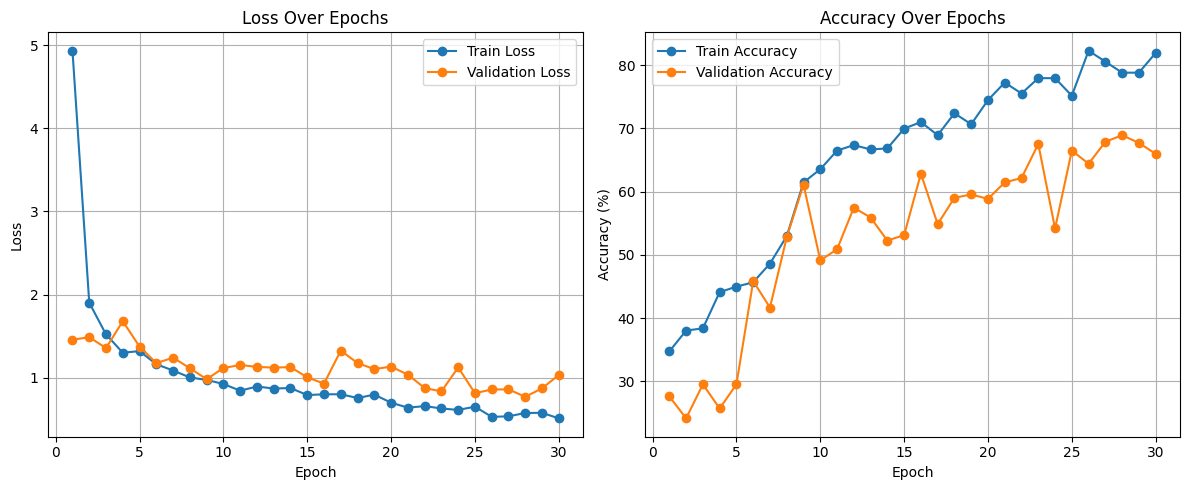

In [126]:
# ========================
# 📈 Plot Loss & Accuracy
# ========================
epochs_range = range(1, num_epochs + 1)
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss', marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Over Epochs")
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Over Epochs")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

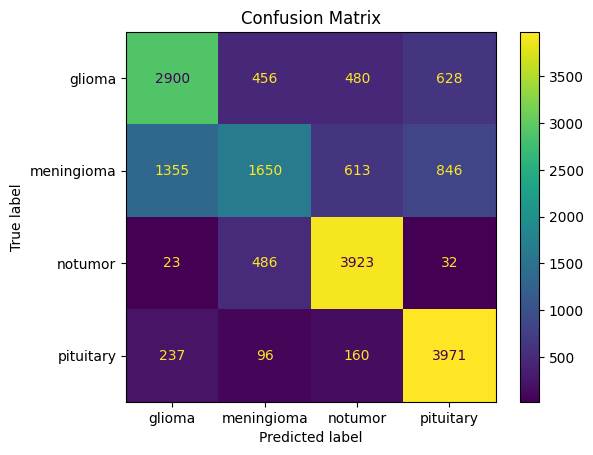

In [127]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(mri_all_labels, mri_all_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['glioma', 'meningioma', 'notumor', 'pituitary'])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [128]:
# Final test accuracy
mri_model.eval()
test_correct = 0
test_total = 0

with torch.inference_mode():
    for images, labels in tqdm(MRI_Data_test):  # Final test set
        images, labels = images.to(device), labels.to(device)
        outputs = mri_model(images)
        _, predicted = torch.max(outputs, 1)

        mri_all_labels.extend(labels.cpu().numpy())
        mri_all_predictions.extend(predicted.cpu().numpy())

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

print(f"✅ Final Test Accuracy: {100 * test_correct / test_total:.2f}%")

100%|██████████| 18/18 [00:04<00:00,  3.82it/s]

✅ Final Test Accuracy: 84.03%
